Raw close prices, per-ticker date ranges:
  gold    : 2010-01-04 to 2026-06-30  (4069 rows)
  bond    : 2010-01-04 to 2026-06-30  (4070 rows)
  vix     : 2010-01-04 to 2026-06-30  (4047 rows)
  equity  : 2010-01-04 to 2026-06-30  (4048 rows)

Missing values per column:
gold       2
bond       1
vix       24
equity    23
dtype: int64

Aligned dataset: 4030 trading days
Date range: 2010-01-04 to 2026-06-30
                 equity       gold        bond        vix
Date                                                     
2010-01-04  5232.200195  16.549900  589.801331  23.639999
2010-01-05  5277.899902  16.680000  589.801331  22.270000
2010-01-06  5281.799805  16.600000  589.801331  22.120001
2010-01-07  5263.100098  16.572001  589.807495  22.500000
2010-01-08  5244.750000  16.490000  589.801331  22.570000

[GLITCH] gold: 4 suspected bad day(s): [datetime.date(2019, 12, 18), datetime.date(2019, 12, 19), datetime.date(2019, 12, 20), datetime.date(2019, 12, 23)]

After glitch repair: 4030 tr

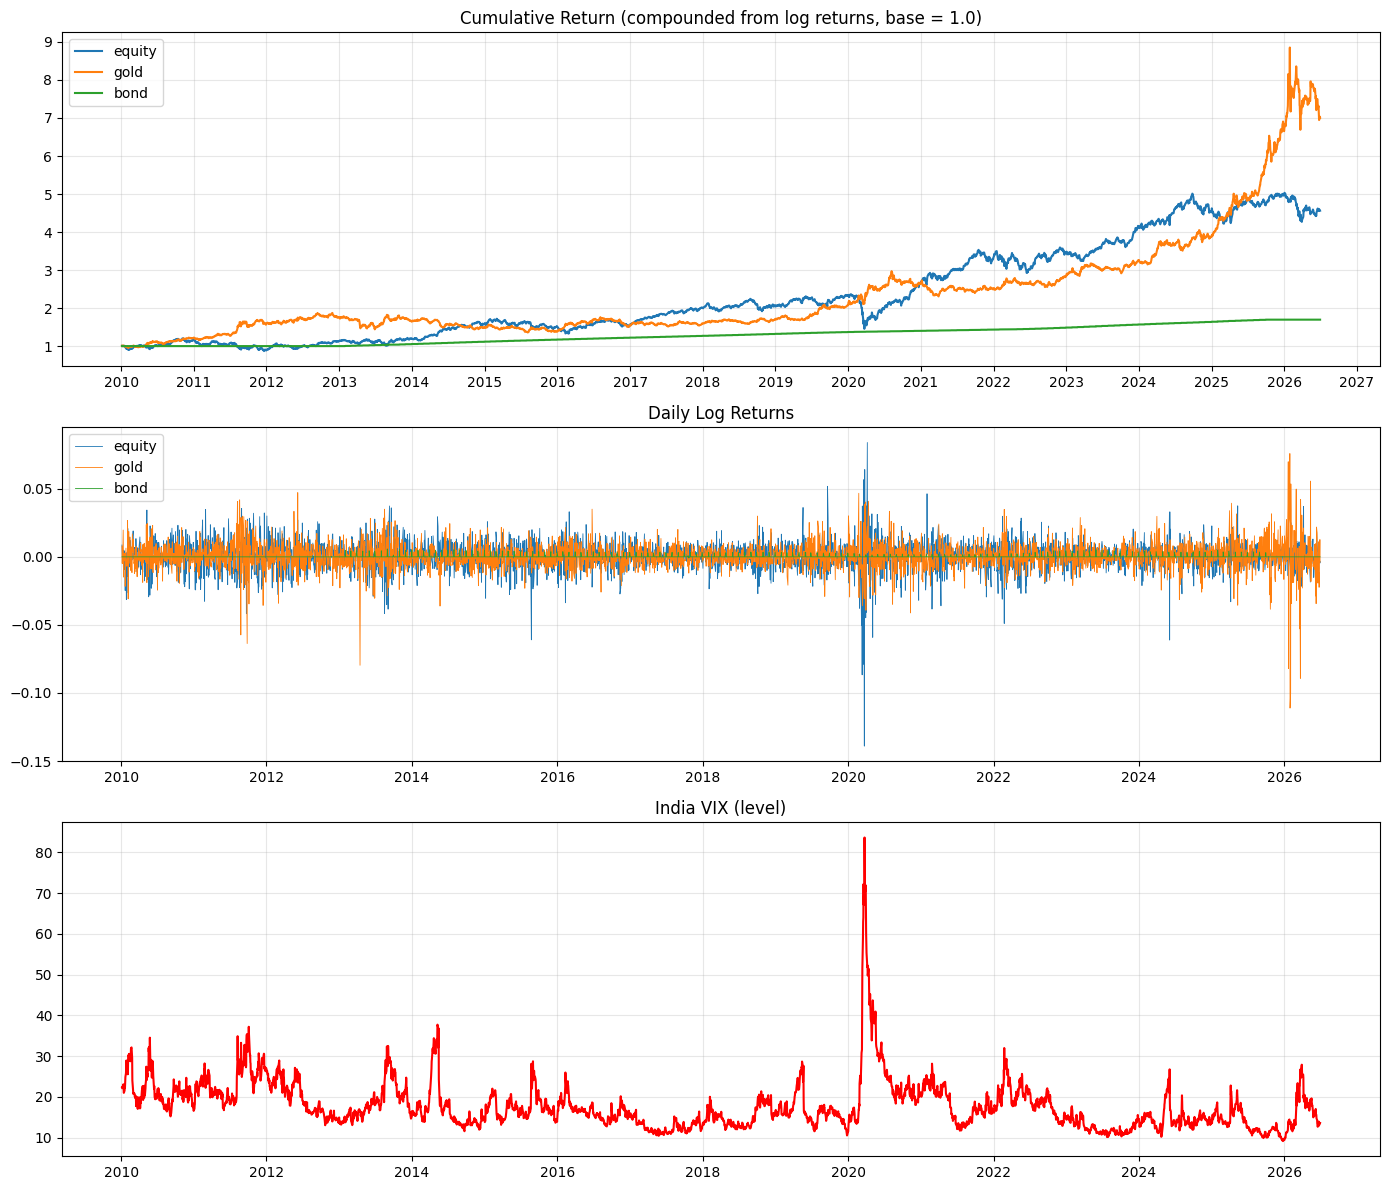


--- Log return summary stats ---
            equity         gold         bond
count  4029.000000  4029.000000  4029.000000
mean      0.000377     0.000483     0.000131
std       0.010471     0.009875     0.000689
min      -0.139038    -0.111117    -0.000880
25%      -0.004852    -0.004197     0.000000
50%       0.000579     0.000322     0.000000
75%       0.006090     0.005084     0.000000
max       0.084003     0.075900     0.005816

--- Correlation matrix (log returns) ---
          equity      gold      bond
equity  1.000000 -0.021453  0.026734
gold   -0.021453  1.000000 -0.017297
bond    0.026734 -0.017297  1.000000

COVID crash 2020: mean VIX = 44.18, max VIX = 83.61 (full-sample mean = 17.75)

2022 stretch: mean VIX = 19.34, max VIX = 31.98 (full-sample mean = 17.75)


In [1]:
"""
Phase 1: Data Pipeline
Pulls daily prices for equity, gold, a bond proxy, and India VIX,
aligns them, cleans glitches, and converts to log returns.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

TICKERS = ["^NSEI", "GOLDBEES.NS", "LIQUIDBEES.NS"]
VIX_TICKER = "^INDIAVIX"

NAME_MAP = {
    "^NSEI": "equity",
    "GOLDBEES.NS": "gold",
    "LIQUIDBEES.NS": "bond",
    "^INDIAVIX": "vix",
}

START = "2010-01-01"
END = "2026-07-01"

# ---- Download ----
all_tickers = TICKERS + [VIX_TICKER]
raw = yf.download(all_tickers, start=START, end=END, progress=False, auto_adjust=True)

close_prices = raw["Close"].copy()
close_prices.columns.name = None
close_prices = close_prices.rename(columns=NAME_MAP)

print("Raw close prices, per-ticker date ranges:")
for col in close_prices.columns:
    s = close_prices[col].dropna()
    print(f"  {col:8s}: {s.index.min().date()} to {s.index.max().date()}  ({len(s)} rows)")

print("\nMissing values per column:")
print(close_prices.isna().sum())

# ---- Align ----
asset_cols = ["equity", "gold", "bond"]
asset_prices = close_prices[asset_cols]
vix_level = close_prices["vix"]

prices = asset_prices.join(vix_level, how="inner").dropna()

print(f"\nAligned dataset: {prices.shape[0]} trading days")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
print(prices.head())

# ---- Glitch detection and repair ----
ratio_prev = prices[asset_cols] / prices[asset_cols].shift(1)
ratio_next = prices[asset_cols] / prices[asset_cols].shift(-1)
glitch_mask = (ratio_prev > 3) | (ratio_prev < 1 / 3) | (ratio_next > 3) | (ratio_next < 1 / 3)

for col in asset_cols:
    bad_dates = prices.index[glitch_mask[col].fillna(False)]
    if len(bad_dates) > 0:
        print(f"\n[GLITCH] {col}: {len(bad_dates)} suspected bad day(s): "
              f"{[d.date() for d in bad_dates]}")
        prices.loc[bad_dates, col] = np.nan

prices[asset_cols] = prices[asset_cols].interpolate(method="linear")
prices = prices.dropna()

print(f"\nAfter glitch repair: {prices.shape[0]} trading days remain")
prices.to_csv("aligned_prices.csv")

# ---- Log returns ----
log_returns = np.log(prices[asset_cols]).diff().dropna()
log_returns.to_csv("daily_log_returns.csv")
vix_aligned = prices["vix"].reindex(log_returns.index)

# ---- Plots ----
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

cum_return = np.exp(log_returns.cumsum())
axes[0].plot(cum_return.index, cum_return)
axes[0].legend(cum_return.columns)
axes[0].set_title("Cumulative Return (compounded from log returns, base = 1.0)")
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].grid(alpha=0.3)

axes[1].plot(log_returns.index, log_returns, lw=0.6)
axes[1].legend(log_returns.columns)
axes[1].set_title("Daily Log Returns")
axes[1].grid(alpha=0.3)

axes[2].plot(vix_aligned.index, vix_aligned, color="red")
axes[2].set_title("India VIX (level)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("phase1_sanity_check.png", dpi=150)
plt.show()

# ---- Sanity stats ----
print("\n--- Log return summary stats ---")
print(log_returns.describe())

print("\n--- Correlation matrix (log returns) ---")
print(log_returns.corr())

# ---- Crisis-window check ----
for label, (start, end) in {
    "COVID crash 2020": ("2020-02-15", "2020-04-15"),
    "2022 stretch": ("2022-01-01", "2022-12-31"),
}.items():
    window = vix_aligned.loc[start:end]
    if len(window) > 0:
        print(f"\n{label}: mean VIX = {window.mean():.2f}, max VIX = {window.max():.2f} "
              f"(full-sample mean = {vix_aligned.mean():.2f})")
    else:
        print(f"\n{label}: no data in this window")

Feature matrix shape: (3967, 11)
Date range: 2010-04-08 to 2026-06-30

Feature summary stats:
            mom_5d      mom_21d      mom_63d       vol_5d      vol_21d  \
count  3967.000000  3967.000000  3967.000000  3967.000000  3967.000000   
mean      0.001894     0.007994     0.024493     0.138358     0.148557   
std       0.023508     0.048925     0.079445     0.092106     0.074437   
min      -0.211017    -0.465848    -0.476821     0.015586     0.050638   
25%      -0.011034    -0.017240    -0.022976     0.083040     0.104176   
50%       0.003169     0.010420     0.032671     0.118633     0.135411   
75%       0.016093     0.038394     0.076398     0.167947     0.172786   
max       0.101681     0.198613     0.310674     1.335954     0.894625   

           vol_63d  drawdown_126d  drawdown_252d    vix_level   vix_chg_5d  \
count  3967.000000    3967.000000    3967.000000  3967.000000  3967.000000   
mean      0.153152      -0.049737      -0.057496    17.662670    -0.005442   
std  

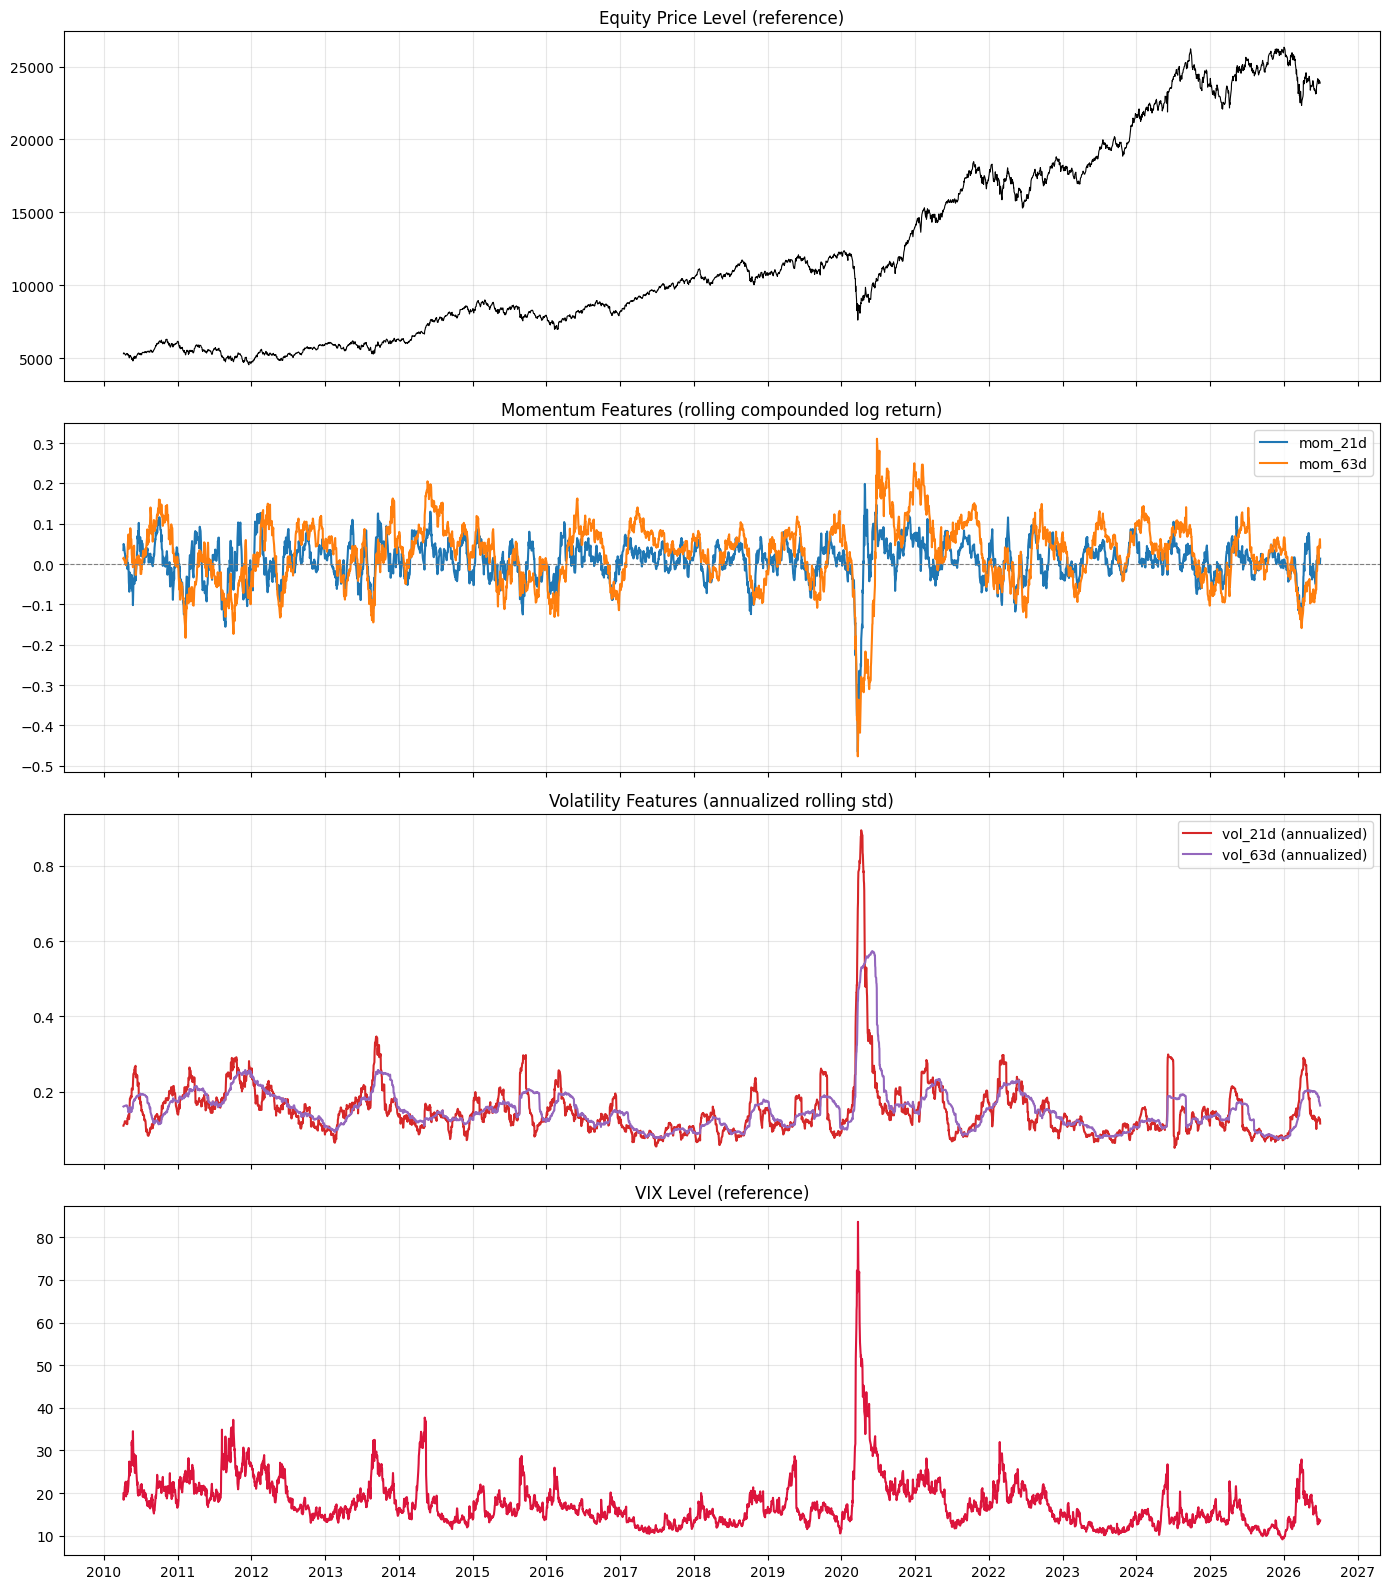


COVID crash 2020:
  mean 21d momentum : -0.1907  (full-sample mean: +0.0080)
  mean 21d vol (ann): 0.4728  (full-sample mean: 0.1486)
  mean VIX level    : 44.18  (full-sample mean: 17.66)
  mean 126d drawdown: -20.15%  (full-sample mean: -4.97%)

2022 stretch:
  mean 21d momentum : +0.0059  (full-sample mean: +0.0080)
  mean 21d vol (ann): 0.1661  (full-sample mean: 0.1486)
  mean VIX level    : 19.34  (full-sample mean: 17.66)
  mean 126d drawdown: -5.97%  (full-sample mean: -4.97%)

Feature correlation matrix:
               mom_5d  mom_21d  mom_63d  vol_5d  vol_21d  vol_63d  \
mom_5d           1.00     0.49     0.26   -0.17    -0.01     0.03   
mom_21d          0.49     1.00     0.54   -0.44    -0.32    -0.08   
mom_63d          0.26     0.54     1.00   -0.42    -0.50    -0.42   
vol_5d          -0.17    -0.44    -0.42    1.00     0.73     0.51   
vol_21d         -0.01    -0.32    -0.50    0.73     1.00     0.77   
vol_63d          0.03    -0.08    -0.42    0.51     0.77     1.00 

In [2]:
"""
Phase 2: Feature Engineering
Builds momentum, volatility, drawdown, and VIX-derived features from
Phase 1's aligned prices and log returns.
"""

prices = pd.read_csv("aligned_prices.csv", index_col=0, parse_dates=True)
log_returns = pd.read_csv("daily_log_returns.csv", index_col=0, parse_dates=True)
vix = prices["vix"].reindex(log_returns.index)
equity_ret = log_returns["equity"]
equity_price = prices["equity"].reindex(log_returns.index)

# ---- Momentum ----
MOM_WINDOWS = {"mom_5d": 5, "mom_21d": 21, "mom_63d": 63}
momentum = pd.DataFrame(index=log_returns.index)
for name, window in MOM_WINDOWS.items():
    momentum[name] = equity_ret.rolling(window).sum()

# ---- Volatility (annualized) ----
VOL_WINDOWS = {"vol_5d": 5, "vol_21d": 21, "vol_63d": 63}
volatility = pd.DataFrame(index=log_returns.index)
for name, window in VOL_WINDOWS.items():
    volatility[name] = equity_ret.rolling(window).std() * np.sqrt(252)

# ---- Drawdown from rolling peak ----
DRAWDOWN_WINDOWS = {"drawdown_126d": 126, "drawdown_252d": 252}
drawdown = pd.DataFrame(index=log_returns.index)
for name, window in DRAWDOWN_WINDOWS.items():
    rolling_peak = equity_price.rolling(window, min_periods=1).max()
    drawdown[name] = equity_price / rolling_peak - 1.0

# ---- VIX-derived ----
vix_features = pd.DataFrame(index=log_returns.index)
vix_features["vix_level"] = vix
vix_features["vix_chg_5d"] = vix.diff(5)
vix_features["vix_chg_21d"] = vix.diff(21)

# ---- Combine ----
features = pd.concat([momentum, volatility, drawdown, vix_features], axis=1).dropna()

print(f"Feature matrix shape: {features.shape}")
print(f"Date range: {features.index.min().date()} to {features.index.max().date()}")
print("\nFeature summary stats:")
print(features.describe())

features.to_csv("engineered_features.csv")

# ---- Sanity-check plots ----
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

axes[0].plot(prices["equity"].reindex(features.index), color="black", lw=0.8)
axes[0].set_title("Equity Price Level (reference)")
axes[0].grid(alpha=0.3)

axes[1].plot(features.index, features["mom_21d"], label="mom_21d", color="tab:blue")
axes[1].plot(features.index, features["mom_63d"], label="mom_63d", color="tab:orange")
axes[1].axhline(0, color="grey", lw=0.8, ls="--")
axes[1].set_title("Momentum Features (rolling compounded log return)")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(features.index, features["vol_21d"], label="vol_21d (annualized)", color="tab:red")
axes[2].plot(features.index, features["vol_63d"], label="vol_63d (annualized)", color="tab:purple")
axes[2].set_title("Volatility Features (annualized rolling std)")
axes[2].legend()
axes[2].grid(alpha=0.3)

axes[3].plot(features.index, features["vix_level"], color="crimson")
axes[3].set_title("VIX Level (reference)")
axes[3].xaxis.set_major_locator(mdates.YearLocator())
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("phase2_feature_sanity_check.png", dpi=150)
plt.show()

# ---- Crisis-window sanity check ----
CRISIS_WINDOWS = {
    "COVID crash 2020": ("2020-02-15", "2020-04-15"),
    "2022 stretch": ("2022-01-01", "2022-12-31"),
}

for label, (start, end) in CRISIS_WINDOWS.items():
    window = features.loc[start:end]
    if len(window) == 0:
        print(f"\n{label}: no data in this window")
        continue
    print(f"\n{label}:")
    print(f"  mean 21d momentum : {window['mom_21d'].mean():+.4f}  "
          f"(full-sample mean: {features['mom_21d'].mean():+.4f})")
    print(f"  mean 21d vol (ann): {window['vol_21d'].mean():.4f}  "
          f"(full-sample mean: {features['vol_21d'].mean():.4f})")
    print(f"  mean VIX level    : {window['vix_level'].mean():.2f}  "
          f"(full-sample mean: {features['vix_level'].mean():.2f})")
    print(f"  mean 126d drawdown: {window['drawdown_126d'].mean():+.2%}  "
          f"(full-sample mean: {features['drawdown_126d'].mean():+.2%})")

# ---- Feature correlation ----
print("\nFeature correlation matrix:")
print(features.corr().round(2))

In [3]:
pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 1.2 MB/s eta 0:00:00


Feature matrix for HMM: (3967, 6)
           mom_21d      mom_63d      vol_21d  drawdown_126d    vix_level  \
count  3967.000000  3967.000000  3967.000000    3967.000000  3967.000000   
mean      0.007994     0.024493     0.148557      -0.049737    17.662670   
std       0.048925     0.079445     0.074437       0.051315     6.007570   
min      -0.465848    -0.476821     0.050638      -0.384399     9.150000   
25%      -0.017240    -0.022976     0.104176      -0.077515    13.800000   
50%       0.010420     0.032671     0.135411      -0.033690    16.379999   
75%       0.038394     0.076398     0.172786      -0.009498    20.095000   
max       0.198613     0.310674     0.894625       0.000000    83.610001   

        vix_chg_5d  
count  3967.000000  
mean     -0.005442  
std       2.573846  
min     -19.649998  
25%      -1.030000  
50%      -0.070000  
75%       0.960001  
max      33.240002  
Best log-likelihood across 25 restarts: -22138.63
Model converged: True

Per-state feature m

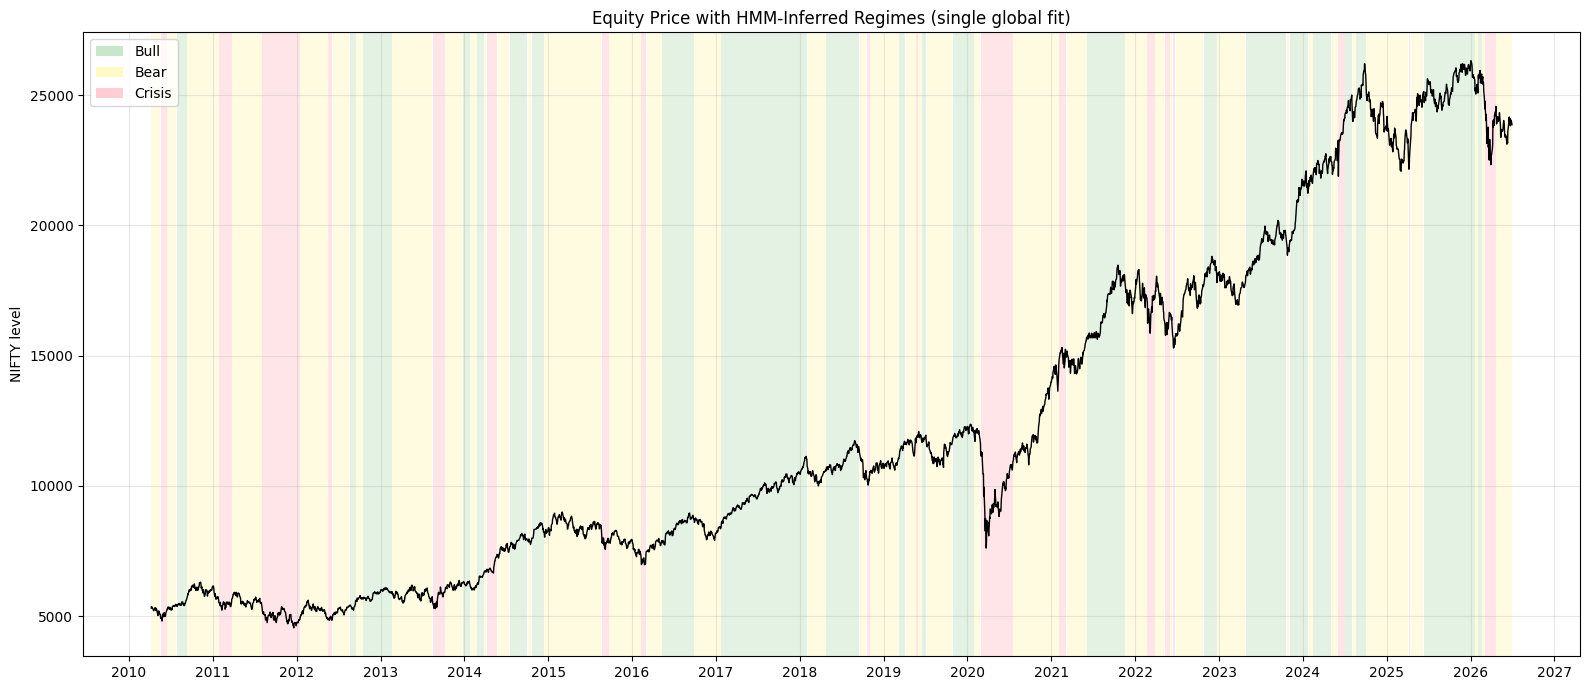


COVID crash 2020 regime breakdown:
regime
Crisis    0.78
Bear      0.22
Name: proportion, dtype: float64

2022 stretch regime breakdown:
regime
Bear      0.63
Crisis    0.21
Bull      0.16
Name: proportion, dtype: float64


In [4]:
"""
Phase 3: HMM Regime Classifier
Fits a 3-state Gaussian HMM on a trimmed feature set to produce a
Bull / Bear / Crisis label for every trading day.

"""

from matplotlib.patches import Patch
from hmmlearn.hmm import GaussianHMM

features = pd.read_csv("engineered_features.csv", index_col=0, parse_dates=True)
prices = pd.read_csv("aligned_prices.csv", index_col=0, parse_dates=True)

SELECTED = ["mom_21d", "mom_63d", "vol_21d", "drawdown_126d", "vix_level", "vix_chg_5d"]
X_raw = features[SELECTED].copy()

print(f"Feature matrix for HMM: {X_raw.shape}")
print(X_raw.describe())

# ---- Standardize (full-sample z-score) ----
mu = X_raw.mean()
sigma = X_raw.std()
X = (X_raw - mu) / sigma
X_values = X.values

# ---- Fit HMM with multiple restarts (avoids bad local optima) ----
N_STATES = 3
N_RESTARTS = 25

best_model = None
best_score = -np.inf

for seed in range(N_RESTARTS):
    candidate = GaussianHMM(
        n_components=N_STATES,
        covariance_type="diag",
        n_iter=1000,
        tol=1e-4,
        random_state=seed,
    )
    candidate.fit(X_values)
    score = candidate.score(X_values)
    if score > best_score:
        best_score = score
        best_model = candidate

model = best_model
print(f"Best log-likelihood across {N_RESTARTS} restarts: {best_score:.2f}")
print(f"Model converged: {model.monitor_.converged}")

# ---- Decode state sequence (Viterbi) ----
hidden_states = model.predict(X_values)
X["raw_state"] = hidden_states

# ---- Map state numbers to Bull/Bear/Crisis ----
state_stats = X_raw.groupby(hidden_states).mean()
state_stats["n_days"] = pd.Series(hidden_states).value_counts().sort_index()
print("\nPer-state feature means (RAW, unstandardized) and day counts:")
print(state_stats)

# Confirm states are distinct, not two near-duplicates
pairwise_dists = []
for i in range(N_STATES):
    for j in range(i + 1, N_STATES):
        dist = np.linalg.norm(model.means_[i] - model.means_[j])
        pairwise_dists.append((i, j, dist))
        print(f"  Distance between state {i} and state {j} (standardized units): {dist:.2f}")
min_dist = min(d for _, _, d in pairwise_dists)
if min_dist < 0.5:
    print(f"\n[WARNING] Two states are still very close together (distance={min_dist:.2f}). "
          f"Consider: more restarts, covariance_type='full', or revisiting the feature set.")
else:
    print(f"\nStates look reasonably well separated (min pairwise distance = {min_dist:.2f}).")

vol_rank = state_stats["vol_21d"].sort_values(ascending=False)
crisis_state = vol_rank.index[0]
remaining = [s for s in state_stats.index if s != crisis_state]

if state_stats.loc[remaining[0], "drawdown_126d"] <= state_stats.loc[remaining[1], "drawdown_126d"]:
    bear_state, bull_state = remaining[0], remaining[1]
else:
    bear_state, bull_state = remaining[1], remaining[0]

label_map = {bull_state: "Bull", bear_state: "Bear", crisis_state: "Crisis"}
print(f"\nState label mapping: {label_map}")

# Honesty check: is "Bear" actually declining, or just choppy?
bear_mom = state_stats.loc[bear_state, "mom_63d"]
bear_dd = state_stats.loc[bear_state, "drawdown_126d"]
if bear_mom > 0 and bear_dd > -0.05:
    print(f"[NOTE] The 'Bear' state has mom_63d={bear_mom:+.3f} and "
          f"drawdown_126d={bear_dd:+.2%} -- both close to flat/positive. "
          f"This looks more like 'choppy/consolidating' than a true decline.")

regime = pd.Series(hidden_states, index=X_raw.index).map(label_map)
regime.name = "regime"
regime.to_csv("regime_labels.csv")

print("\nDays per regime:")
print(regime.value_counts())

# ---- Transition matrix ----
transmat_df = pd.DataFrame(
    model.transmat_,
    index=[label_map[i] for i in range(N_STATES)],
    columns=[label_map[i] for i in range(N_STATES)],
)
order = ["Bull", "Bear", "Crisis"]
transmat_df = transmat_df.loc[order, order]
print("\nTransition probability matrix (row = from, column = to):")
print(transmat_df.round(3))
transmat_df.to_csv("transition_matrix.csv")

# ---- Plot: price chart with regime bands ----
equity_price = prices["equity"].reindex(regime.index)

fig, ax = plt.subplots(figsize=(16, 7))
colors = {"Bull": "#c8e6c9", "Bear": "#fff9c4", "Crisis": "#ffcdd2"}

regime_shift = (regime != regime.shift()).cumsum()
for _, block in regime.groupby(regime_shift):
    r = block.iloc[0]
    ax.axvspan(block.index[0], block.index[-1], color=colors[r], alpha=0.5, lw=0)

ax.plot(equity_price.index, equity_price, color="black", lw=1)
ax.set_title("Equity Price with HMM-Inferred Regimes (single global fit)")
ax.set_ylabel("NIFTY level")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

legend_handles = [Patch(facecolor=colors[r], edgecolor="none", label=r) for r in order]
ax.legend(handles=legend_handles, loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("phase3_regime_overlay.png", dpi=150)
plt.show()

# ---- Crisis-window check ----
CRISIS_WINDOWS = {
    "COVID crash 2020": ("2020-02-15", "2020-04-15"),
    "2022 stretch": ("2022-01-01", "2022-12-31"),
}
for label, (start, end) in CRISIS_WINDOWS.items():
    window = regime.loc[start:end]
    if len(window) == 0:
        continue
    print(f"\n{label} regime breakdown:")
    print(window.value_counts(normalize=True).round(2))

Total days available: 3967
Refit at 2013-04-26 | train_days=750 | loglik=-4550.3 | labels={0: 'Bull', 1: 'Bear', np.int64(2): 'Crisis'}
Refit at 2013-07-25 | train_days=813 | loglik=-5000.8 | labels={0: 'Bull', 1: 'Bear', np.int64(2): 'Crisis'}
Refit at 2013-10-29 | train_days=876 | loglik=-5450.9 | labels={0: 'Bull', 1: 'Bear', np.int64(2): 'Crisis'}
Refit at 2014-01-30 | train_days=939 | loglik=-5837.4 | labels={0: 'Bull', 1: 'Bear', np.int64(2): 'Crisis'}
Refit at 2014-05-09 | train_days=1002 | loglik=-6341.9 | labels={1: 'Bull', 0: 'Bear', np.int64(2): 'Crisis'}
Refit at 2014-08-07 | train_days=1065 | loglik=-6671.9 | labels={0: 'Bull', 1: 'Bear', np.int64(2): 'Crisis'}
Refit at 2014-11-18 | train_days=1128 | loglik=-7004.8 | labels={0: 'Bull', 2: 'Bear', np.int64(1): 'Crisis'}
Refit at 2015-02-19 | train_days=1191 | loglik=-7444.6 | labels={0: 'Bull', 2: 'Bear', np.int64(1): 'Crisis'}
Refit at 2015-05-27 | train_days=1254 | loglik=-7874.1 | labels={0: 'Bull', 1: 'Bear', np.int64(2

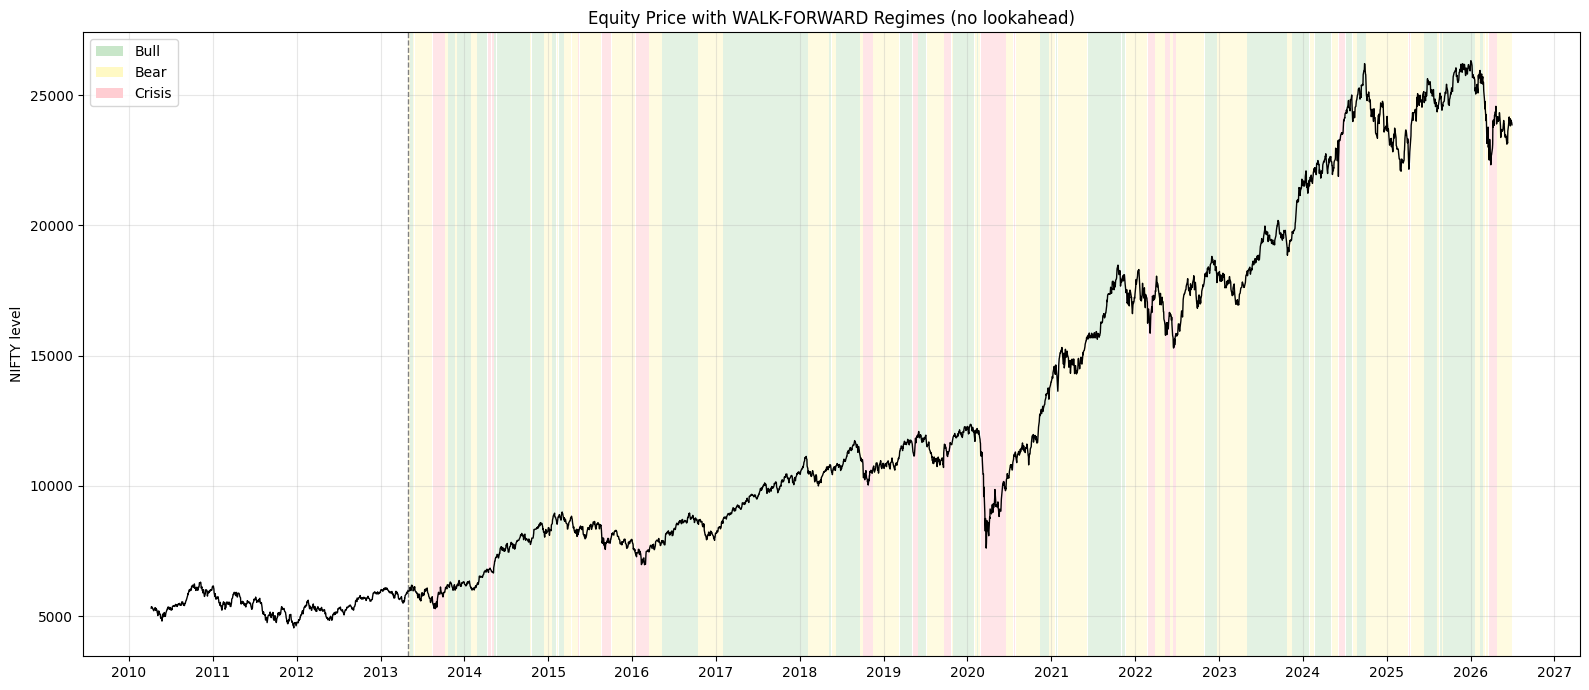


COVID crash 2020 regime breakdown (walk-forward, real-time-honest):
regime_walkforward
Crisis    0.78
Bear      0.19
Bull      0.03
Name: proportion, dtype: float64

2022 stretch regime breakdown (walk-forward, real-time-honest):
regime_walkforward
Bear      0.66
Crisis    0.18
Bull      0.15
Name: proportion, dtype: float64

Overall walk-forward regime day counts:
regime_walkforward
Bull      1435
Bear      1421
Crisis     361
Name: count, dtype: int64


In [5]:
"""
Phase 4: Walk-Forward Validation
Re-fits the HMM inside expanding windows so every regime label uses only
data available up to and including that day -- no lookahead.

Every 63 trading days the model is refit from scratch on data up to that
point; the scaler is fit on the same training-only slice. Within a test
window, each day is decoded causally on its own (not the whole window at
once), and state labels are re-derived per refit from training data only.
"""

import time

features = pd.read_csv("engineered_features.csv", index_col=0, parse_dates=True)
prices = pd.read_csv("aligned_prices.csv", index_col=0, parse_dates=True)

SELECTED = ["mom_21d", "mom_63d", "vol_21d", "drawdown_126d", "vix_level", "vix_chg_5d"]
X_all_raw = features[SELECTED].copy()

N = len(X_all_raw)
print(f"Total days available: {N}")

INITIAL_TRAIN_DAYS = 750
RETRAIN_EVERY = 63
N_STATES = 3
N_RESTARTS = 10


def fit_hmm_multi_restart(X_scaled, n_states, n_restarts):
    best_model, best_score = None, -np.inf
    for seed in range(n_restarts):
        candidate = GaussianHMM(
            n_components=n_states,
            covariance_type="diag",
            n_iter=500,
            tol=1e-4,
            random_state=seed,
        )
        candidate.fit(X_scaled)
        score = candidate.score(X_scaled)
        if score > best_score:
            best_score, best_model = score, candidate
    return best_model, best_score


def derive_label_map(X_raw_train, hidden_states_train, n_states):
    """Map state indices -> Bull/Bear/Crisis using only training data."""
    stats = X_raw_train.groupby(hidden_states_train).mean()
    present_states = stats.index.tolist()
    if len(present_states) < n_states:
        vol_rank = stats["vol_21d"].sort_values(ascending=False)
        fallback_map = {}
        for i, s in enumerate(vol_rank.index):
            fallback_map[s] = ["Crisis", "Bear", "Bull"][i] if i < 3 else f"State{s}"
        return fallback_map

    vol_rank = stats["vol_21d"].sort_values(ascending=False)
    crisis_state = vol_rank.index[0]
    remaining = [s for s in present_states if s != crisis_state]
    if stats.loc[remaining[0], "drawdown_126d"] <= stats.loc[remaining[1], "drawdown_126d"]:
        bear_state, bull_state = remaining[0], remaining[1]
    else:
        bear_state, bull_state = remaining[1], remaining[0]
    return {bull_state: "Bull", bear_state: "Bear", crisis_state: "Crisis"}


# ---- Walk-forward loop ----
regime_wf = pd.Series(index=X_all_raw.index, dtype=object)
refit_log = []

train_end = INITIAL_TRAIN_DAYS
start_time = time.time()

while train_end < N:
    test_end = min(train_end + RETRAIN_EVERY, N)

    X_train_raw = X_all_raw.iloc[:train_end]
    mu = X_train_raw.mean()
    sigma = X_train_raw.std()
    X_train_scaled = ((X_train_raw - mu) / sigma).values

    model, score = fit_hmm_multi_restart(X_train_scaled, N_STATES, N_RESTARTS)
    hidden_train = model.predict(X_train_scaled)
    label_map = derive_label_map(X_train_raw, hidden_train, N_STATES)

    train_cutoff_date = X_all_raw.index[train_end - 1]
    refit_log.append({
        "train_cutoff": train_cutoff_date,
        "train_days": train_end,
        "log_likelihood": score,
        "label_map": label_map,
    })
    print(f"Refit at {train_cutoff_date.date()} | train_days={train_end} | "
          f"loglik={score:.1f} | labels={label_map}")

    # Causal, day-by-day decode -- each day uses only data through that day
    for t in range(train_end, test_end):
        X_causal_raw = X_all_raw.iloc[:t + 1]
        X_causal_scaled = ((X_causal_raw - mu) / sigma).values
        state_today = model.predict(X_causal_scaled)[-1]
        regime_wf.iloc[t] = label_map.get(state_today, f"State{state_today}")

    train_end = test_end

elapsed = time.time() - start_time
print(f"\nWalk-forward complete in {elapsed:.1f}s. "
      f"{regime_wf.notna().sum()} days labeled "
      f"(first {INITIAL_TRAIN_DAYS} days have no label -- no model existed yet).")

regime_wf.name = "regime_walkforward"
regime_wf.to_csv("regime_labels_walkforward.csv")

# ---- Leakage check ----
leakage_found = False
train_end_check = INITIAL_TRAIN_DAYS
for log in refit_log:
    test_end_check = min(train_end_check + RETRAIN_EVERY, N)
    test_dates = X_all_raw.index[train_end_check:test_end_check]
    if len(test_dates) > 0 and log["train_cutoff"] >= test_dates.min():
        leakage_found = True
        print(f"[LEAKAGE] train cutoff {log['train_cutoff']} >= test start {test_dates.min()}")
    train_end_check = test_end_check
print(f"\nLeakage check: {'FAILED' if leakage_found else 'PASSED'} "
      f"(every training cutoff date is strictly before its test window's dates)")

# ---- Compare to Phase 3's single-global-fit labels ----
try:
    regime_global = pd.read_csv("regime_labels.csv", index_col=0, parse_dates=True).iloc[:, 0]
    common_idx = regime_wf.dropna().index.intersection(regime_global.index)
    agreement = (regime_wf.loc[common_idx] == regime_global.loc[common_idx]).mean()
    print(f"\nAgreement between walk-forward and Phase 3 single-fit labels: {agreement:.1%}")
except FileNotFoundError:
    print("\n(Phase 3 regime_labels.csv not found -- skipping comparison)")

# ---- Plot: walk-forward regimes over price ----
equity_price = prices["equity"].reindex(regime_wf.index)
valid = regime_wf.notna()

fig, ax = plt.subplots(figsize=(16, 7))
colors = {"Bull": "#c8e6c9", "Bear": "#fff9c4", "Crisis": "#ffcdd2"}

regime_valid = regime_wf[valid]
regime_shift = (regime_valid != regime_valid.shift()).cumsum()
for _, block in regime_valid.groupby(regime_shift):
    r = block.iloc[0]
    if r in colors:
        ax.axvspan(block.index[0], block.index[-1], color=colors[r], alpha=0.5, lw=0)

ax.plot(equity_price.index, equity_price, color="black", lw=1)
ax.axvline(X_all_raw.index[INITIAL_TRAIN_DAYS], color="grey", ls="--", lw=1,
           label="Walk-forward starts (no label before this)")
ax.set_title("Equity Price with WALK-FORWARD Regimes (no lookahead)")
ax.set_ylabel("NIFTY level")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

legend_handles = [Patch(facecolor=colors[r], edgecolor="none", label=r) for r in ["Bull", "Bear", "Crisis"]]
ax.legend(handles=legend_handles, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("phase4_walkforward_regime_overlay.png", dpi=150)
plt.show()

# ---- Crisis-window check ----
CRISIS_WINDOWS = {
    "COVID crash 2020": ("2020-02-15", "2020-04-15"),
    "2022 stretch": ("2022-01-01", "2022-12-31"),
}
for label, (start, end) in CRISIS_WINDOWS.items():
    window = regime_wf.loc[start:end].dropna()
    if len(window) == 0:
        print(f"\n{label}: no walk-forward labels available in this window")
        continue
    print(f"\n{label} regime breakdown (walk-forward, real-time-honest):")
    print(window.value_counts(normalize=True).round(2))

print("\nOverall walk-forward regime day counts:")
print(regime_wf.dropna().value_counts())

Aligned dataset for optimization: 3217 days
Days per regime:
regime_walkforward
Bull      1435
Bear      1421
Crisis     361
Name: count, dtype: int64

--- Checkpoint weights (full walk-forward history, NOT causal -- sanity check only) ---
        equity   gold   bond
Bull     0.304  0.203  0.493
Bear     0.198  0.102  0.700
Crisis   0.088  0.212  0.700


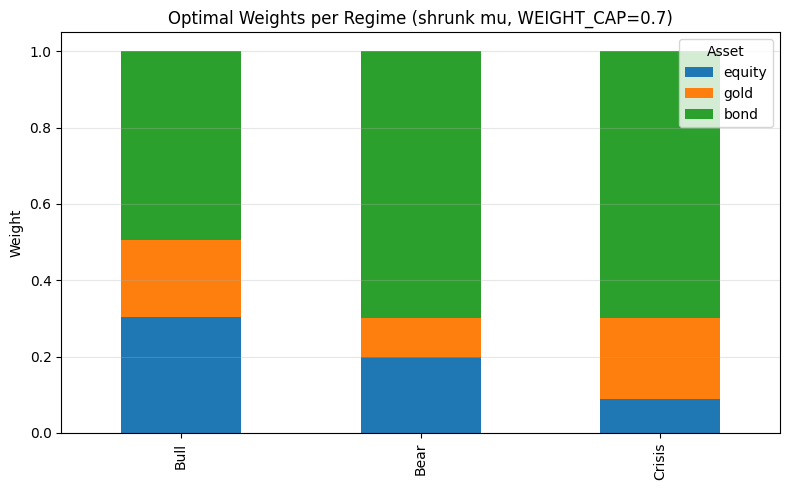


Smell test:
  Equity weight -- Bull: 0.30, Crisis: 0.09
  Passes: Crisis allocates less to equity than Bull, as expected.

--- rf sensitivity check (Bull regime only) ---
  rf=0.0: equity=0.170, gold=0.130, bond=0.700
  rf=0.00024: equity=0.304, gold=0.203, bond=0.493

compute_regime_weights() is the function Phase 6 calls inside its walk-forward loop, using only each window's training slice.


In [6]:
"""
Phase 5: Portfolio Optimization per Regime
Defines a per-regime objective (max Sharpe / balanced / min variance) and
solves for optimal long-only weights using cvxpy.

Mean returns are shrunk toward the cross-asset grand mean before
optimization (sample means are the noisiest input to mean-variance
optimizers), and a WEIGHT_CAP bounds any single asset's allocation --
both guard against noise-driven corner solutions.

"""

import cvxpy as cp

ASSETS = ["equity", "gold", "bond"]
REGIME_ORDER = ["Bull", "Bear", "Crisis"]

RF_DAILY = 0.00024      # ~6% annualized, approx India overnight/repo rate
WEIGHT_CAP = 0.7
MU_SHRINKAGE = 0.3      # 0 = raw sample mean, 1 = fully flat (grand mean only)

log_returns = pd.read_csv("daily_log_returns.csv", index_col=0, parse_dates=True)
regime_wf = pd.read_csv("regime_labels_walkforward.csv", index_col=0, parse_dates=True).iloc[:, 0]

common_idx = log_returns.index.intersection(regime_wf.dropna().index)
returns_aligned = log_returns.loc[common_idx, ASSETS]
regime_aligned = regime_wf.loc[common_idx]

print(f"Aligned dataset for optimization: {len(common_idx)} days")
print("Days per regime:")
print(regime_aligned.value_counts())

MIN_DAYS_FOR_COV = 30


# ---- Shrinkage helpers ----

def shrink_cov(cov, shrinkage=0.1):
    diag_target = np.diag(np.diag(cov))
    return (1 - shrinkage) * cov + shrinkage * diag_target


def shrink_mu(mu, shrinkage=MU_SHRINKAGE):
    grand_mean = np.mean(mu)
    return (1 - shrinkage) * mu + shrinkage * grand_mean


# ---- Solvers ----

def _weight_constraints(w):
    constraints = [cp.sum(w) == 1, w >= 0]
    if WEIGHT_CAP is not None:
        constraints.append(w <= WEIGHT_CAP)
    return constraints


def solve_max_sharpe(mu, cov, rf=RF_DAILY):
    n = len(mu)
    excess = mu - rf
    if not np.any(excess > 1e-8):
        return None
    y = cp.Variable(n)
    kappa = cp.Variable(nonneg=True)
    constraints = [cp.sum(y) == kappa, excess @ y == 1, kappa >= 1e-6, y >= 0]
    if WEIGHT_CAP is not None:
        constraints.append(y <= WEIGHT_CAP * kappa)
    try:
        prob = cp.Problem(cp.Minimize(cp.quad_form(y, cp.psd_wrap(cov))), constraints)
        prob.solve()
    except cp.error.SolverError:
        return None
    if y.value is None or kappa.value is None or kappa.value < 1e-8:
        return None
    w = np.clip(y.value / kappa.value, 0, None)
    return w / w.sum()


def solve_min_variance(mu, cov):
    n = len(mu)
    w = cp.Variable(n)
    try:
        prob = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov))), _weight_constraints(w))
        prob.solve()
        return w.value
    except cp.error.SolverError:
        return None


def solve_balanced(mu, cov, risk_aversion=3.0):
    n = len(mu)
    w = cp.Variable(n)
    try:
        prob = cp.Problem(
            cp.Maximize(mu @ w - risk_aversion * cp.quad_form(w, cp.psd_wrap(cov))),
            _weight_constraints(w),
        )
        prob.solve()
        return w.value
    except cp.error.SolverError:
        return None


def bull_solver(mu, cov):
    w = solve_max_sharpe(mu, cov)
    if w is None:
        w = solve_balanced(mu, cov, risk_aversion=1.0)
    return w


REGIME_SOLVERS = {
    "Bull": bull_solver,
    "Bear": lambda mu, cov: solve_balanced(mu, cov, risk_aversion=3.0),
    "Crisis": lambda mu, cov: solve_min_variance(mu, cov),
}


def compute_regime_weights(returns_slice, regime_slice, equal_weight_fallback=True):
    """CAUSAL as long as the caller only passes a training slice (e.g. Phase 6's
    window up to day t). Returns dict {regime: weights np.array, order=ASSETS}."""
    weights = {}
    for regime in REGIME_ORDER:
        mask = regime_slice == regime
        n_days = mask.sum()

        w = None
        if n_days >= MIN_DAYS_FOR_COV:
            r = returns_slice.loc[mask]
            mu = shrink_mu(r.mean().values, shrinkage=MU_SHRINKAGE)
            cov = shrink_cov(r.cov().values, shrinkage=0.1)
            w = REGIME_SOLVERS[regime](mu, cov)

        if w is None and equal_weight_fallback:
            w = np.repeat(1 / len(ASSETS), len(ASSETS))
        weights[regime] = w
    return weights


# ---- Checkpoint: full-history weights (sanity check only, NOT for backtest) ----
checkpoint_weights = compute_regime_weights(returns_aligned, regime_aligned)

print("\n--- Checkpoint weights (full walk-forward history, NOT causal -- sanity check only) ---")
weights_df = pd.DataFrame(checkpoint_weights, index=ASSETS).T.loc[REGIME_ORDER]
print(weights_df.round(3))
weights_df.to_csv("regime_weights_checkpoint.csv")

fig, ax = plt.subplots(figsize=(8, 5))
weights_df.plot(kind="bar", stacked=True, ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set_title(f"Optimal Weights per Regime (shrunk mu, WEIGHT_CAP={WEIGHT_CAP})")
ax.set_ylabel("Weight")
ax.legend(title="Asset")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("phase5_regime_weights_checkpoint.png", dpi=150)
plt.show()

print("\nSmell test:")
print(f"  Equity weight -- Bull: {weights_df.loc['Bull', 'equity']:.2f}, "
      f"Crisis: {weights_df.loc['Crisis', 'equity']:.2f}")
if weights_df.loc["Crisis", "equity"] >= weights_df.loc["Bull", "equity"]:
    print("  [WARNING] Crisis equity weight is NOT lower than Bull's -- "
          "check regime labeling / feature set before trusting this.")
else:
    print("  Passes: Crisis allocates less to equity than Bull, as expected.")

# ---- rf sensitivity check (Bull regime only) ----
print("\n--- rf sensitivity check (Bull regime only) ---")
for rf_test in [0.0, 0.00024]:
    r_bull = returns_aligned.loc[regime_aligned == "Bull"]
    mu_bull = shrink_mu(r_bull.mean().values, shrinkage=MU_SHRINKAGE)
    cov_bull = shrink_cov(r_bull.cov().values, shrinkage=0.1)
    w_bull = solve_max_sharpe(mu_bull, cov_bull, rf=rf_test)
    if w_bull is None:
        w_bull = solve_balanced(mu_bull, cov_bull, risk_aversion=1.0)
    print(f"  rf={rf_test}: " + ", ".join(f"{a}={w:.3f}" for a, w in zip(ASSETS, w_bull)))

print("\ncompute_regime_weights() is the function Phase 6 calls inside its "
      "walk-forward loop, using only each window's training slice.")

Backtest universe: 3216 days, 2013-04-30 to 2026-06-30
Transitions -- raw: 104, confirmed: 86

=== Performance Summary ===
                                             Ann. Return  Ann. Vol  Sharpe  \
Dynamic (Regime, raw) (cost=0.0bps)               0.0683    0.0855  0.7993   
Dynamic (Regime, hysteresis) (cost=0.0bps)        0.0802    0.0910  0.8819   
Static 60/40 (cost=0.0bps)                        0.0852    0.0960  0.8873   
Equal Weight (cost=0.0bps)                        0.0950    0.0737  1.2895   
Dynamic (Regime, raw) (cost=5.0bps)               0.0662    0.0855  0.7741   
Dynamic (Regime, hysteresis) (cost=5.0bps)        0.0783    0.0910  0.8611   
Static 60/40 (cost=5.0bps)                        0.0852    0.0960  0.8869   
Equal Weight (cost=5.0bps)                        0.0950    0.0737  1.2889   
Dynamic (Regime, raw) (cost=7.5bps)               0.0651    0.0855  0.7614   
Dynamic (Regime, hysteresis) (cost=7.5bps)        0.0774    0.0910  0.8507   
Static 60/40 (cost=

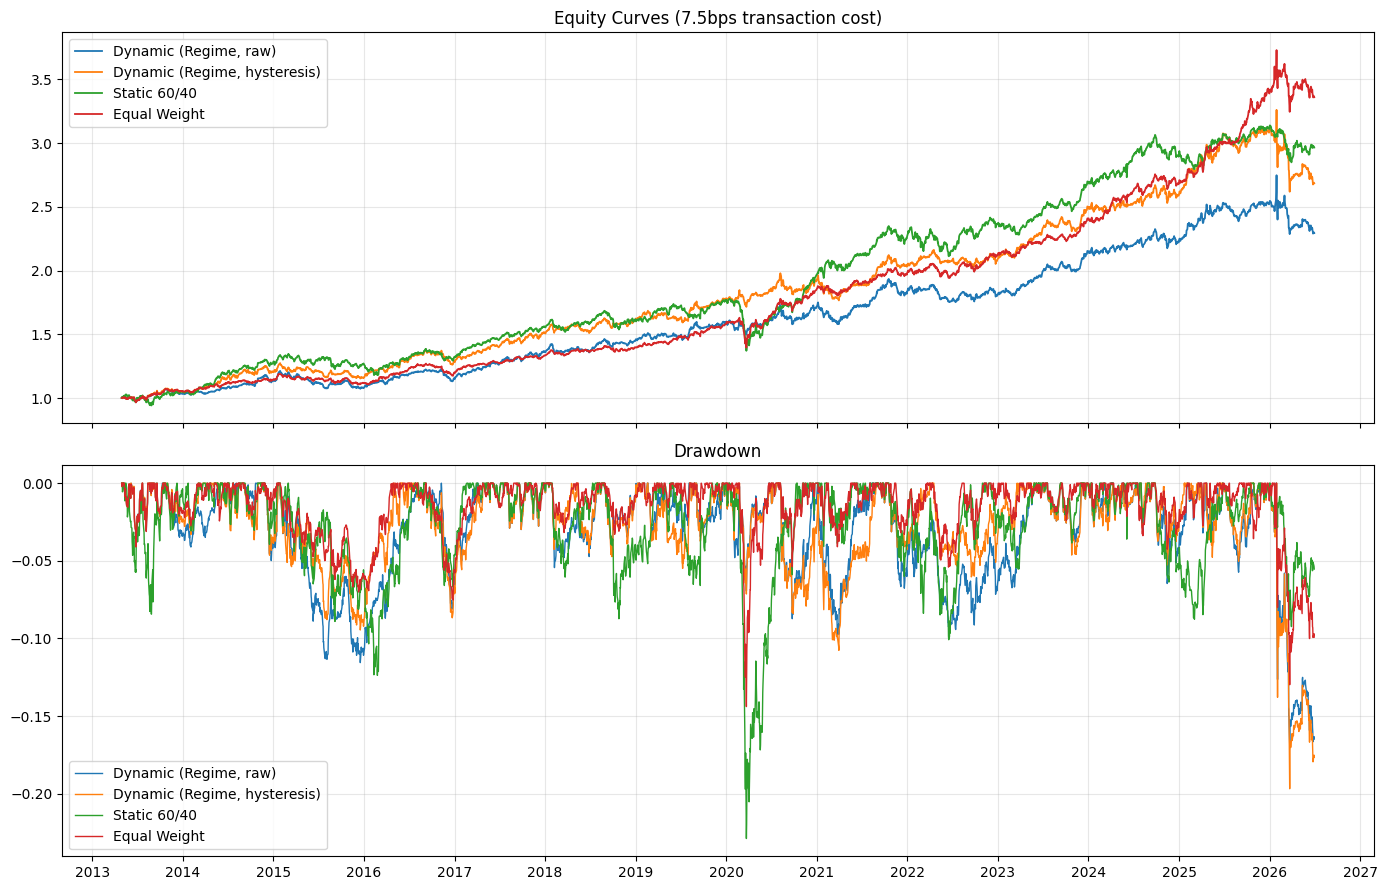


Causality check: PASSED (3216/3216)


In [7]:
"""
Phase 6: Backtest with Transaction Costs
Builds a causal, walk-forward regime-driven portfolio and compares it
against static 60/40 and equal-weight benchmarks using Sharpe, Sortino,
max drawdown, Calmar ratio, and turnover -- with and without transaction costs.

"""

ASSETS = ["equity", "gold", "bond"]
REGIME_ORDER = ["Bull", "Bear", "Crisis"]

RF_DAILY = 0.00024
WEIGHT_CAP = 0.7
MU_SHRINKAGE = 0.3
MIN_DAYS_FOR_COV = 30

REWEIGHT_EVERY = 63
REBALANCE_EVERY = 63
MIN_PERSIST = 3
COST_BPS_LIST = [0.0, 5.0, 7.5, 10.0]

# ---- Load data, shift regime by 1 day (yesterday's regime decides today's holding) ----
log_returns = pd.read_csv("daily_log_returns.csv", index_col=0, parse_dates=True)
regime_wf = pd.read_csv("regime_labels_walkforward.csv", index_col=0, parse_dates=True).iloc[:, 0]

common_idx = log_returns.index.intersection(regime_wf.dropna().index)
returns_aligned = log_returns.loc[common_idx, ASSETS]
regime_aligned = regime_wf.loc[common_idx]

regime_shifted = regime_aligned.shift(1)
valid_idx = regime_shifted.dropna().index
returns_bt = returns_aligned.loc[valid_idx]
regime_bt = regime_shifted.loc[valid_idx]
n = len(valid_idx)

print(f"Backtest universe: {n} days, {valid_idx.min().date()} to {valid_idx.max().date()}")


# ---- Hysteresis: confirm a regime only after MIN_PERSIST consecutive days ----
def apply_hysteresis(regime_series, min_persist=3):
    effective = regime_series.copy()
    current = regime_series.iloc[0]
    candidate, candidate_count = current, 0
    effective.iloc[0] = current

    for i in range(1, len(regime_series)):
        label = regime_series.iloc[i]
        if label == current:
            candidate, candidate_count = current, 0
        else:
            candidate_count = candidate_count + 1 if label == candidate else 1
            candidate = label
            if candidate_count >= min_persist:
                current = candidate
                candidate_count = 0
        effective.iloc[i] = current
    return effective


regime_bt_confirmed = apply_hysteresis(regime_bt, min_persist=MIN_PERSIST)

raw_transitions = (regime_bt != regime_bt.shift(1)).sum()
confirmed_transitions = (regime_bt_confirmed != regime_bt_confirmed.shift(1)).sum()
print(f"Transitions -- raw: {raw_transitions}, confirmed: {confirmed_transitions}")


# ---- Phase 5 optimizer (self-contained) ----
def shrink_cov(cov, shrinkage=0.1):
    return (1 - shrinkage) * cov + shrinkage * np.diag(np.diag(cov))

def shrink_mu(mu, shrinkage=MU_SHRINKAGE):
    return (1 - shrinkage) * mu + shrinkage * np.mean(mu)

def _weight_constraints(w):
    c = [cp.sum(w) == 1, w >= 0]
    if WEIGHT_CAP is not None:
        c.append(w <= WEIGHT_CAP)
    return c

def solve_max_sharpe(mu, cov, rf=RF_DAILY):
    n_ = len(mu)
    excess = mu - rf
    if not np.any(excess > 1e-8):
        return None
    y = cp.Variable(n_)
    kappa = cp.Variable(nonneg=True)
    constraints = [cp.sum(y) == kappa, excess @ y == 1, kappa >= 1e-6, y >= 0]
    if WEIGHT_CAP is not None:
        constraints.append(y <= WEIGHT_CAP * kappa)
    try:
        cp.Problem(cp.Minimize(cp.quad_form(y, cp.psd_wrap(cov))), constraints).solve()
    except cp.error.SolverError:
        return None
    if y.value is None or kappa.value is None or kappa.value < 1e-8:
        return None
    w = np.clip(y.value / kappa.value, 0, None)
    return w / w.sum()

def solve_min_variance(mu, cov):
    w = cp.Variable(len(mu))
    try:
        cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov))), _weight_constraints(w)).solve()
        return w.value
    except cp.error.SolverError:
        return None

def solve_balanced(mu, cov, risk_aversion=3.0):
    w = cp.Variable(len(mu))
    try:
        cp.Problem(cp.Maximize(mu @ w - risk_aversion * cp.quad_form(w, cp.psd_wrap(cov))),
                   _weight_constraints(w)).solve()
        return w.value
    except cp.error.SolverError:
        return None

def bull_solver(mu, cov):
    w = solve_max_sharpe(mu, cov)
    return w if w is not None else solve_balanced(mu, cov, risk_aversion=1.0)

REGIME_SOLVERS = {
    "Bull": bull_solver,
    "Bear": lambda mu, cov: solve_balanced(mu, cov, risk_aversion=3.0),
    "Crisis": lambda mu, cov: solve_min_variance(mu, cov),
}

def compute_regime_weights(returns_slice, regime_slice):
    weights = {}
    for regime in REGIME_ORDER:
        mask = regime_slice == regime
        w = None
        if mask.sum() >= MIN_DAYS_FOR_COV:
            r = returns_slice.loc[mask]
            mu = shrink_mu(r.mean().values)
            cov = shrink_cov(r.cov().values)
            w = REGIME_SOLVERS[regime](mu, cov)
        weights[regime] = w if w is not None else np.repeat(1 / len(ASSETS), len(ASSETS))
    return weights


# ---- Causal, expanding-window target weights ----
def build_dynamic_targets(regime_col):
    target = pd.DataFrame(index=valid_idx, columns=ASSETS, dtype=float)
    current_dict, last_refit_pos = None, -REWEIGHT_EVERY

    for t in range(n):
        if t - last_refit_pos >= REWEIGHT_EVERY:
            train_returns = returns_bt.iloc[:t] if t > 0 else returns_bt.iloc[:1]
            train_regime = regime_col.iloc[:t] if t > 0 else regime_col.iloc[:1]
            if len(train_returns) >= MIN_DAYS_FOR_COV:
                current_dict = compute_regime_weights(train_returns, train_regime)
            last_refit_pos = t
        if current_dict is None:
            target.iloc[t] = 1 / len(ASSETS)
        else:
            today_regime = regime_col.iloc[t]
            target.iloc[t] = current_dict.get(today_regime, np.repeat(1 / len(ASSETS), len(ASSETS)))

    rebalance_flags = (regime_col != regime_col.shift(1))
    rebalance_flags.iloc[0] = True
    return target, rebalance_flags


target_dynamic_raw, rebalance_flags_raw = build_dynamic_targets(regime_bt)
target_dynamic_confirmed, rebalance_flags_confirmed = build_dynamic_targets(regime_bt_confirmed)


# ---- Benchmarks ----
STATIC_6040 = np.array([0.60, 0.00, 0.40])
EQUAL_WEIGHT = np.array([1/3, 1/3, 1/3])

target_static = pd.DataFrame(np.tile(STATIC_6040, (n, 1)), index=valid_idx, columns=ASSETS)
target_equal = pd.DataFrame(np.tile(EQUAL_WEIGHT, (n, 1)), index=valid_idx, columns=ASSETS)

rebalance_flags_periodic = pd.Series(
    [(t % REBALANCE_EVERY == 0) for t in range(n)], index=valid_idx
)


# ---- Backtest engine (turnover = 0.5 * sum(|target - held|)) ----
def run_backtest(returns_df, target_weights_df, rebalance_flags, cost_bps):
    idx = returns_df.index
    n_ = len(idx)
    net_ret = np.zeros(n_)
    gross_ret = np.zeros(n_)
    turnover = np.zeros(n_)

    held = target_weights_df.iloc[0].values.copy()

    for t in range(n_):
        if rebalance_flags.iloc[t]:
            target = target_weights_df.iloc[t].values
            turnover[t] = 0.5 * np.sum(np.abs(target - held))
            held = target.copy()

        cost = turnover[t] * (cost_bps / 10000.0)
        simple_r = np.exp(returns_df.iloc[t].values) - 1.0
        port_simple_r = np.dot(held, simple_r)

        gross_ret[t] = np.log(max(1 + port_simple_r, 1e-8))
        net_ret[t] = np.log(max(1 + port_simple_r - cost, 1e-8))

        drifted = held * (1 + simple_r)
        held = drifted / drifted.sum()

    return (pd.Series(net_ret, index=idx, name="net_log_ret"),
            pd.Series(gross_ret, index=idx, name="gross_log_ret"),
            pd.Series(turnover, index=idx, name="turnover"))


def performance_summary(log_ret, turnover_series, freq=252):
    equity = np.exp(log_ret.cumsum())
    ann_return = log_ret.mean() * freq
    ann_vol = log_ret.std() * np.sqrt(freq)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    downside = log_ret[log_ret < 0]
    downside_vol = downside.std() * np.sqrt(freq) if len(downside) > 1 else np.nan
    sortino = ann_return / downside_vol if downside_vol and downside_vol > 0 else np.nan

    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()

    n_years = len(log_ret) / freq
    calmar = (ann_return / abs(max_dd)) if max_dd != 0 else np.nan
    annual_turnover = turnover_series.sum() / n_years

    return {
        "Ann. Return": ann_return, "Ann. Vol": ann_vol, "Sharpe": sharpe,
        "Sortino": sortino, "Max Drawdown": max_dd, "Calmar": calmar,
        "Annual Turnover": annual_turnover,
    }, equity


# ---- Run all strategies across the cost grid ----
strategies = {
    "Dynamic (Regime, raw)": (target_dynamic_raw, rebalance_flags_raw),
    "Dynamic (Regime, hysteresis)": (target_dynamic_confirmed, rebalance_flags_confirmed),
    "Static 60/40": (target_static, rebalance_flags_periodic),
    "Equal Weight": (target_equal, rebalance_flags_periodic),
}

results = {}
equity_curves = {}

for cost_bps in COST_BPS_LIST:
    for name, (target_df, rebal_flags) in strategies.items():
        net_ret, gross_ret, turn = run_backtest(returns_bt, target_df, rebal_flags, cost_bps)
        summary, equity = performance_summary(net_ret, turn)
        key = f"{name} (cost={cost_bps}bps)"
        results[key] = summary
        equity_curves[key] = equity

summary_df = pd.DataFrame(results).T
summary_df = summary_df[["Ann. Return", "Ann. Vol", "Sharpe", "Sortino", "Max Drawdown", "Calmar", "Annual Turnover"]]
print("\n=== Performance Summary ===")
print(summary_df.round(4))
summary_df.to_csv("phase6_performance_summary.csv")

print("\n=== Raw vs. Hysteresis ===")
print(summary_df.loc[summary_df.index.str.startswith("Dynamic"),
                      ["Ann. Return", "Sharpe", "Calmar", "Annual Turnover"]].round(4))

print("\n=== Cost erosion ===")
for name in strategies:
    rows = summary_df.loc[[f"{name} (cost={c}bps)" for c in COST_BPS_LIST]]
    print(f"\n{name}:")
    print(rows[["Ann. Return", "Sharpe"]].round(4))


# ---- Plots ----
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for name in strategies:
    key = f"{name} (cost=7.5bps)"
    axes[0].plot(equity_curves[key].index, equity_curves[key], label=name, lw=1.3)
axes[0].set_title("Equity Curves (7.5bps transaction cost)")
axes[0].legend()
axes[0].grid(alpha=0.3)

for name in strategies:
    key = f"{name} (cost=7.5bps)"
    eq = equity_curves[key]
    dd = eq / eq.cummax() - 1
    axes[1].plot(dd.index, dd, label=name, lw=1.0)
axes[1].set_title("Drawdown")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("phase6_equity_and_drawdown.png", dpi=150)
plt.show()


# ---- Causality check ----
check = (regime_bt.values == regime_aligned.shift(1).loc[valid_idx].values)
print(f"\nCausality check: {'PASSED' if check.all() else 'FAILED'} ({check.sum()}/{len(check)})")